<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 7

**Load Libraries and Set Up Data**

In [ ]:
# Import necessary libraries
import os
import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Download Dataset via Kagglehub
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
images_dir = os.path.join(path, "img_align_celeba", "img_align_celeba")
attr_path = os.path.join(path, "list_attr_celeba.csv")

# Filter the data
attr_df = pd.read_csv(attr_path)
black_hair_df = attr_df[attr_df['Black_Hair'] == 1].sample(n=5000, random_state=42)
blonde_hair_df = attr_df[attr_df['Blond_Hair'] == 1].sample(n=5000, random_state=42)

# Combine and shuffle
hair_subset = pd.concat([black_hair_df, blonde_hair_df]).sample(frac=1, random_state=42)
train_images = hair_subset['image_id'].values

Using Colab cache for faster access to the 'celeba-dataset' dataset.


In [ ]:
# Define image size as 64 * 64
img_size = 64
# Use 200 dimension to get better quality for the image
latent_dim = 200

# Encoder
encoder_inputs = keras.Input(shape=(img_size, img_size, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

In [ ]:
# VAE Model
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(keras.losses.binary_crossentropy(inputs, reconstruction))
        recon_loss *= (img_size * img_size * 3)
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        self.add_loss(recon_loss + 0.0002 * kl_loss)
        return reconstruction

**Training loop**

In [ ]:
# Image loading
def load_and_preprocess(name):
    img_path = images_dir + "/" + name
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    return tf.cast(img, tf.float32) / 255.0

# Create data pipeline
dataset = tf.data.Dataset.from_tensor_slices(train_images)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Compile and Fit
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.summary()
vae.fit(dataset, epochs=40)

Model: "vae_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 200), (None,   │     2,293,456 │
│                                 │ 200), (None, 200))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │     1,887,299 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,180,755 (15.95 MB)

 Trainable params: 4,180,755 (15.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 6267.9087
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 6121.6123
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 6110.1807
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 6102.1313
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 6098.2612
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 6096.2759
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 6095.4634
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 6102.8096
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 6114.3813
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 6119.5186
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 6120.9653
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 6124.9375
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 6123.5996
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 6119.9692


**Visualization**

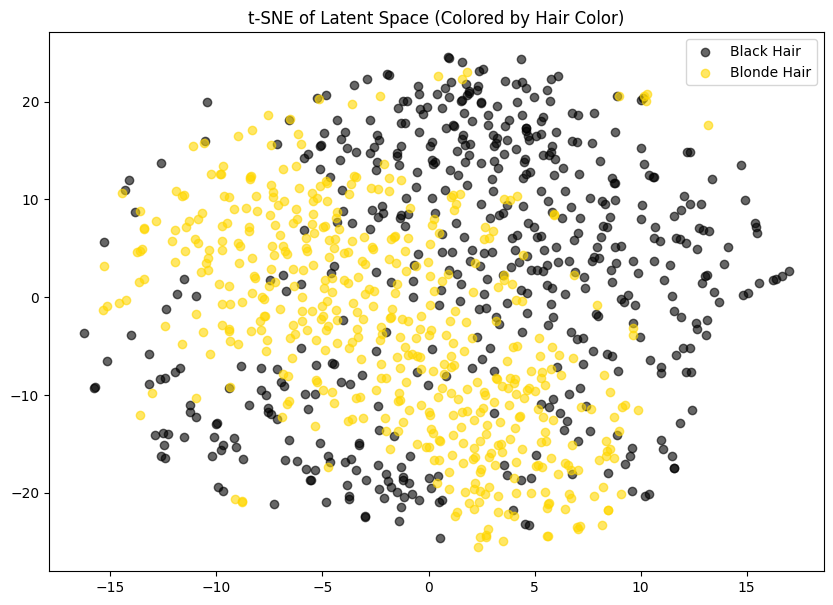

In [ ]:
# Because we can not visualize 200 dimension, so we applied t-SNE to visualize it
def plot_hair_tsne(num_samples=1000):
    sample_df = hair_subset.sample(n=num_samples)
    imgs = np.array([load_and_preprocess(name) for name in sample_df['image_id']])
    z_means, _, _ = encoder.predict(imgs, verbose=0)
    tsne = TSNE(n_components=2, random_state=42)
    z_tsne = tsne.fit_transform(z_means)
    plt.figure(figsize=(10, 7))
    is_blonde = sample_df['Blond_Hair'] == 1
    plt.scatter(z_tsne[~is_blonde, 0], z_tsne[~is_blonde, 1], c='black', label='Black Hair', alpha=0.6)
    plt.scatter(z_tsne[is_blonde, 0], z_tsne[is_blonde, 1], c='gold', label='Blonde Hair', alpha=0.6)
    plt.legend()
    plt.title("t-SNE of Latent Space (Colored by Hair Color)")
    plt.show()

plot_hair_tsne()

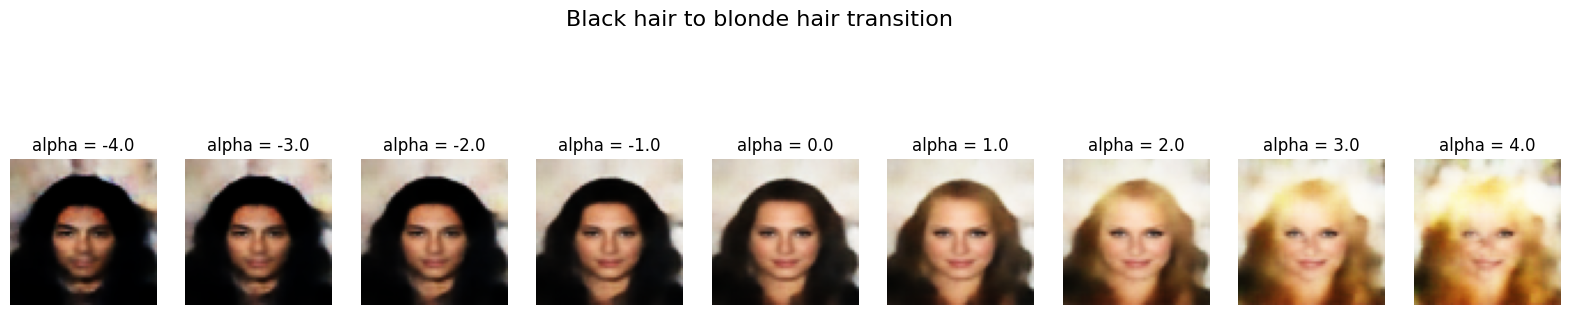

In [ ]:
# Visualization for the black hair to blonde hair transition
def plot_hair_arithmetic():
    f_ids = hair_subset[hair_subset['Blond_Hair'] == 1]['image_id'].sample(500).values
    m_ids = hair_subset[hair_subset['Black_Hair'] == 1]['image_id'].sample(500).values

    def get_avg_z(ids):
        imgs = np.array([load_and_preprocess(i) for i in ids])
        z, _, _ = encoder.predict(imgs, verbose=0)
        return np.mean(z, axis=0)

    hair_vector = get_avg_z(f_ids) - get_avg_z(m_ids)
    test_img = load_and_preprocess(m_ids[0])
    z_base, _, _ = encoder.predict(np.expand_dims(test_img, 0), verbose=0)
    plt.figure(figsize=(20, 4))
    alphas = np.linspace(-4, 4, 9)
    for i, a in enumerate(alphas):
        modified_z = z_base + a * hair_vector
        gen_img = decoder.predict(modified_z, verbose=0)[0]
        plt.subplot(1, 9, i + 1)
        plt.imshow(gen_img)
        plt.title(f"alpha = {a:.1f}")
        plt.axis("off")
    plt.suptitle("Black hair to blonde hair transition", fontsize=16, y=1.05)
    plt.show()

plot_hair_arithmetic()